In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [3]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP
0,1030456,0,1030456,3519,263210,9,2,"[[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...","[[2128, 2128, 2129, 2132, 2132, 2130, 2133, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
1,3274338,0,3274338,3803,263210,9,1,"[[2110, 2200, 2063, 2231, 2197, 2243, 2190, 20...","[[2127, 2132, 2125, 2133, 2132, 2134, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
2,3679960,0,3679960,3805,263210,9,8,"[[2109, 2063, 2115, 2171, 2186, 2107, 2261, 22...","[[2127, 2125, 2128, 2130, 2131, 2127, 2134, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3,6391145,0,6391145,1011,263211,9,1,"[[2085, 2210, 2268, 2181, 2261, 2070, 2185, 21...","[[2126, 2132, 2135, 2131, 2135, 2125, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
4,10916501,0,10916501,1209,263211,9,1,"[[2126, 2191, 2261, 2007, 2195, 2182, 2129, 22...","[[2128, 2131, 2135, 2122, 2131, 2131, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 123,..."
...,...,...,...,...,...,...,...,...,...,...
3157,316424396,9,9316424396,7915,266398,9,8,"[[2152, 2187, 2166, 2148, 2147, 2127, 2174, 21...","[[2129, 2131, 2130, 2129, 2129, 2128, 2130, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3158,321000985,9,9321000985,8402,266398,9,9,"[[2113, 2050, 2263, 2073, 2132, 2078, 2293, 20...","[[2127, 2124, 2135, 2125, 2128, 2126, 2136, 21...","[[255, 255, 255, 158, 255, 255, 255, 255, 255,..."
3159,326043880,9,9326043880,1403,266399,9,9,"[[2385, 2234, 2198, 2229, 2154, 2125, 2167, 21...","[[2141, 2133, 2132, 2133, 2129, 2128, 2130, 21...","[[117, 255, 255, 255, 255, 255, 255, 255, 255,..."
3160,329345615,9,9329345615,2419,266399,9,6,"[[2147, 2090, 2225, 2220, 2201, 2126, 2132, 22...","[[2129, 2126, 2133, 2133, 2132, 2128, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."


In [4]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [24]:

# ======================= FUNZIONI GEOMETRICHE =======================
def intersection(p1, d1, p2, d2, eps_det=1e-6, eps_ang=1e-1):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:          # <<<
        return None                     # <<<

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1


def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])


def peso_angolare(d1, d2):
    d1 = d1 / np.linalg.norm(d1)
    d2 = d2 / np.linalg.norm(d2)
    return abs(d1[0]*d2[1] - d1[1]*d2[0])


# ======================= CALCOLO EVENTI VERI =======================

inters_hg = []
dist_hg = []
inters_lg = []
dist_lg = []

dfR = pd.DataFrame(results)

# ===================== HG =====================
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):
    rette_evth = df_evt["HG"].values
    rette_evtl = df_evt["LG"].values

    # ----------- HG -----------
    for i in range(len(rette_evth)):
        tel1 = rette_evth[i]["tel"]
        for j in range(i+1, len(rette_evth)):
            tel2 = rette_evth[j]["tel"]
            if tel1 == tel2:
                continue

            d1 = rette_evth[i]["d"]          # 
            d2 = rette_evth[j]["d"]          # 

            # ignora rette quasi parallele
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-3:   # in realtà già lo fa l'intersezione è ridondante
                continue                                 # 

            P = intersection(
                rette_evth[i]["p0"], d1,
                rette_evth[j]["p0"], d2
            )

            if P is None:
                continue

            #if np.linalg.norm(P) > 400:
                #continue
            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i,j)
            })

    # ----------- LG -----------
    for i in range(len(rette_evtl)):
        tel1 = rette_evtl[i]["tel"]
        for j in range(i+1, len(rette_evtl)):
            tel2 = rette_evtl[j]["tel"]
            if tel1 == tel2:
                continue

            d1 = rette_evtl[i]["d"]          # 
            d2 = rette_evtl[j]["d"]          # 

            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-1:   #taglio le rette quasi parallele
                continue                                 # 

            P = intersection(
                rette_evtl[i]["p0"], d1,
                rette_evtl[j]["p0"], d2
            )

            if P is None:
                continue

            #if np.linalg.norm(P) > 400:
                #continue

            centro_lg = P
            median_lg = P

            d_mean = []
            d_median = []

            for r in rette_evtl:
                p0 = r["p0"]
                d  = r["d"]
                d_mean.append(d_punto_retta(centro_lg, p0, d))
                d_median.append(d_punto_retta(median_lg, p0, d))
            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i,j)
            })


# ===================== DATAFRAME FINALI =====================

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)


P_hg = np.vstack(df_int_hg["P"].values)
P_lg = np.vstack(df_int_lg["P"].values)


# ===================== VERSIONS VETTORIALI =====================
def d_punto_retta_vec(P, p0, d):
    """
    Calcola distanza di più rette da un punto P
    P : (2,)
    p0: (N,2)
    d : (N,2)
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [ ]:
from sklearn.cluster import DBSCAN

# Parametri DBSCAN
epsilon = 5
min_samples = 1   # <<< attenzione: ogni punto è cluster valido con 1

# ======================= HG =======================
dist_hg = []
df_int_hg = pd.DataFrame(inters_hg)

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[(dfR["event"] == event) & (dfR["mcrun"] == mcrun), "HG"]
    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        df_evt_P = df_evt[labels == lab].reset_index(drop=True)

        # ---------- calcolo pesi angolari ----------
        w_cl = []
        for idx, row in df_evt_P.iterrows():
            i, j = row["pair"]
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w = (abs(d1[0]*d2[1] - d1[1]*d2[0]))**2
            w_cl.append(w)
        w_cl = np.array(w_cl)

        # media pesata e non pesata
        P_mean   = np.average(Pcl, axis=0, weights=w_cl)
        P_mean_simple = np.mean(Pcl, axis=0)
        P_median = np.median(Pcl, axis=0)

        # ---------- DEBUG ORGANIZZATO ----------
        print(f"\n=== Event {event}, MCRun {mcrun}, Cluster {lab} ===")
        print(f"Numero punti nel cluster: {len(Pcl)}")
        print(f"Pesi: min {w_cl.min():.4f}, max {w_cl.max():.4f}, media {w_cl.mean():.4f}")
        print(f"Media semplice: {P_mean_simple}")
        print(f"Media pesata:  {P_mean}")
        print(f"Differenza media pesata - semplice: {P_mean - P_mean_simple}")
        print("======================================")

        dist_mean   = d_punto_retta_vec(P_mean,   p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)

        for t, dm, dmed in zip(tel, dist_mean, dist_median):
            dist_hg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_mean": P_mean.copy(),
                "P_median": P_median.copy(),
                "d_mean": dm,
                "d_median": dmed
            })

df_dist_hg = pd.DataFrame(dist_hg)

# ======================= LG =======================
dist_lg = []
df_int_lg = pd.DataFrame(inters_lg)

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[(dfR["event"] == event) & (dfR["mcrun"] == mcrun), "LG"]
    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        df_evt_P = df_evt[labels == lab].reset_index(drop=True)

        # ---------- calcolo pesi angolari ----------
        w_cl = []
        for idx, row in df_evt_P.iterrows():
            i, j = row["pair"]
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w = (abs(d1[0]*d2[1] - d1[1]*d2[0]))**2
            w_cl.append(w)
        w_cl = np.array(w_cl)

        P_mean   = np.average(Pcl, axis=0, weights=w_cl)
        P_mean_simple = np.mean(Pcl, axis=0)
        P_median = np.median(Pcl, axis=0)

        # ---------- DEBUG ----------
        print(f"\n=== Event {event}, MCRun {mcrun}, Cluster {lab} (LG) ===")
        print(f"Numero punti nel cluster: {len(Pcl)}")
        print(f"Pesi: min {w_cl.min():.4f}, max {w_cl.max():.4f}, media {w_cl.mean():.4f}")
        print(f"Media semplice: {P_mean_simple}")
        print(f"Media pesata:  {P_mean}")
        print(f"Differenza media pesata - semplice: {P_mean - P_mean_simple}")
        print("======================================")

        dist_mean   = d_punto_retta_vec(P_mean,   p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)

        for t, dm, dmed in zip(tel, dist_mean, dist_median):
            dist_lg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_mean": P_mean.copy(),
                "P_median": P_median.copy(),
                "d_mean": dm,
                "d_median": dmed
            })

df_dist_lg = pd.DataFrame(dist_lg)



=== Event 100, MCRun 263751, Cluster 0 ===
Numero punti nel cluster: 4
Pesi: min 0.0137, max 0.0180, media 0.0164
Media semplice: [35.50229268 13.92112264]
Media pesata:  [35.35384492 13.85669659]
Differenza media pesata - semplice: [-0.14844776 -0.06442605]

=== Event 100, MCRun 263751, Cluster 1 ===
Numero punti nel cluster: 2
Pesi: min 0.0224, max 0.0276, media 0.0250
Media semplice: [57.89444115 12.61129353]
Media pesata:  [57.78755477 12.52272794]
Differenza media pesata - semplice: [-0.10688638 -0.08856559]

=== Event 100, MCRun 263751, Cluster 2 ===
Numero punti nel cluster: 2
Pesi: min 0.0106, max 0.0356, media 0.0231
Media semplice: [46.75689648 12.6656536 ]
Media pesata:  [47.35955678 13.06626233]
Differenza media pesata - semplice: [0.60266031 0.40060873]

=== Event 100, MCRun 263751, Cluster 3 ===
Numero punti nel cluster: 1
Pesi: min 0.0106, max 0.0106, media 0.0106
Media semplice: [91.70656963 13.69738102]
Media pesata:  [91.70656963 13.69738102]
Differenza media pesata 

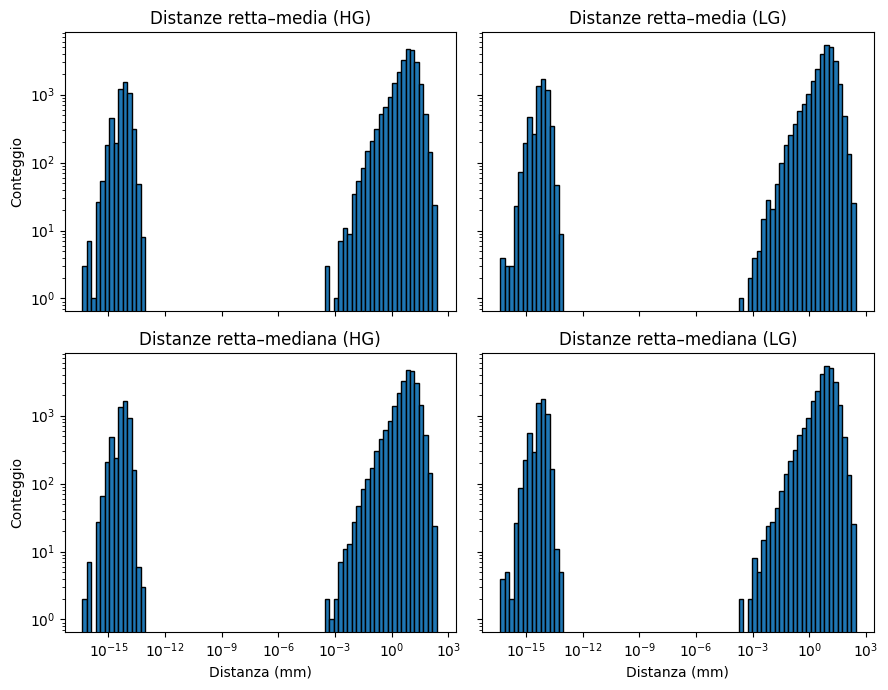

In [27]:
d_mean_hg   = df_dist_hg["d_mean"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg   = df_dist_lg["d_mean"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# binnaggi
bins_mean_hg = np.logspace(np.log10(d_mean_hg.min()), np.log10(d_mean_hg.max()), 80)
bins_median_hg = np.logspace(np.log10(d_median_hg.min()), np.log10(d_median_hg.max()), 80)
bins_mean_lg = np.logspace(np.log10(d_mean_lg.min()), np.log10(d_mean_lg.max()), 80)
bins_median_lg = np.logspace(np.log10(d_median_lg.min()), np.log10(d_median_lg.max()), 80)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg , edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")

   # scala log solo ora che sappiamo che i dati sono validi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()
